# Yield Curve Construction & Discounting
### FINM3422 - Assessment 3 | Risk & Derivatives Platform

---

__Purpose:__ This notebook constructs and validates the yield curve module, which forms the interest rate infrastructure layer for the derivative platform. It provides the term-dependent risk-free rates used to discount future cash flows (e.g., expected option payoffs) to present value.

---

## 1.0 Background

### 1.1 What is a Yield Curve?

The yield curve describes the relationship between annualised interest rates (yields) and time to maturity for risk-free borrowing and lending. Formally, it is the function:

$$T \mapsto z(T)$$

- Where, $z(T)$ is the annualised zero-coupon rate applicable to a single cash flow occuring at time $T$ (in years).

### 1.2 What is the Discount Factor?

A discount factor, $D(T)$ converts a future cash flow into its present value. Continuous compounding was used in the construction of the yield curve. Continuous compounding was chosen (over annual) as it is aligned with the Black-Scholes framework.

$$D(T) = e^{-z(T) \cdot T}$$

- Where, $r(T)$ is the risk-free annualised rate applicable to maturity $T$ (in years).

In option pricing, the discount factor is applied to the expected payoff under a risk-neutral measure.

### 1.3 Why do we need it?

In risk-neutral valuation, the price of any derivative is the expected payoff discounted at the risk-free rate:

$$\text{Option Price} = D(T) \cdot \mathbb{E}^Q[\text{Payoff at } T]$$

- Where, $\mathbb{Q}$ denotes the risk-neutral measure and $D(T)$ is the discount rate derived from the yield curve.

The discount rate $D(T)$ must be maturity-specific. Using a single flat rate across all maturities ignores the term structure and introduces pricing error, especially for longer-dated options.

### 1.4 Data Source

Data was obtained from the __RBA F17 Zero-coupon Interest Rates__ (Analytical Series), downloaded directly from the Reserve Bank of Australia.

| Property | Detail |
|---|---|
| Source | Reserve Bank of Australia |
| Series | F17 – Zero-coupon Interest Rates (Analytical) |
| Date Range | 2017-01-03 to 2026-04-30  |
| Maturities | 0yr to 10yr in 0.25yr increments (41 points) |
| Units | Per cent per annum (converted to decimals on load) |
| URL | https://www.rba.gov.au/statistics/tables/ |







## 2.0 Environment & Imports

In [1]:
# Import the necessary packages and libraries.
import sys, os

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import HTML

# Print versions for loaded packages and libraries.
print()
try:
    print (f"sys: Version {sys.version}")
    print(f"numpy: Version {np.__version__}")
    print(f"pandas: Version {pd.__version__}")
    print(f"matplotlib: Version {plt.matplotlib.__version__}")
    print(f"seaborn: Version {sns.__version__}")
except NameError:
    print("One or more libraries failed to load — check errors above.")

# Add the project root to Python's path so src/ modules can be imported across all machines.
sys.path.append(os.path.abspath('..'))

from src.data_loader_yieldcurve import load_yield_curve_data, get_latest_yields
from src.yield_curve import YieldCurve

# For consistency, display all float values to 4 decimal places (unless specifically formatted differently).
pd.set_option ("display.float_format", "{:.4f}".format)


sys: Version 3.14.4 (tags/v3.14.4:23116f9, Apr  7 2026, 14:10:54) [MSC v.1944 64 bit (AMD64)]
numpy: Version 2.4.4
pandas: Version 3.0.3
matplotlib: Version 3.10.9
seaborn: Version 0.13.2


## 3.0 Load & Inspect Data

Firstly, the cleaned dataset is loaded and the most recent observations are inspected to confirm the data pipeline is working correctly.

In [ ]:
# Load the full cleaned data set from the cached CSV.
df = load_yield_curve_data()

# Select a representative subset of maturities across the curve (instead of all 41 maturities).
display_cols = [0, 0.25, 0.5, 0.75, 1.0, 1.5, 2.0, 3.0, 4.0, 5.0, 7.0, 10.0] 

# Extract the 5 most recent trading days, convert to % p.a. and rename columns for readability.
recent = df[["date"] + display_cols].tail(5).copy()
recent[display_cols] = recent[display_cols] * 100
recent.columns = ["Date"] + [f"{m}yr" for m in display_cols]
recent["Date"] = recent["Date"].dt.strftime("%d-%m-%Y")

# Hide the index by replacing it with blank strings.
recent = recent.reset_index(drop=True)
recent.index = [""] * len(recent)

# Display the representative data.
print("Most recent 5 trading days (% p.a.):")
display(recent)

[data_loader] Loaded from cache: c:\Users\indig\OneDrive\Documents\FINM3422-Financial Modelling\A3-FINM3422\FINM3422_A3_T7_G1_DP\src\..\data\F17_DATA_CLEAN.csv
Most recent 5 trading days (% p.a.):


,Date,0yr,0.25yr,0.5yr,0.75yr,1.0yr,1.5yr,2.0yr,3.0yr,4.0yr,5.0yr,7.0yr,10.0yr
,24-04-2026,4.1000,4.2900,4.4200,4.5100,4.5600,4.6100,4.6100,4.6200,4.6300,4.6700,4.7800,4.9500
,27-04-2026,4.1000,4.2800,4.4200,4.5100,4.5700,4.6100,4.6100,4.6100,4.6300,4.6700,4.7800,4.9600
,28-04-2026,4.1000,4.3000,4.4500,4.5400,4.5900,4.6400,4.6500,4.6500,4.6700,4.7100,4.8200,5.0000
,29-04-2026,4.1000,4.2800,4.4100,4.5000,4.5500,4.6000,4.6100,4.6100,4.6400,4.6800,4.7900,4.9700
,30-04-2026,4.1000,4.3000,4.4600,4.5600,4.6300,4.6800,4.6900,4.6900,4.7100,4.7500,4.8600,5.0400


## 4.0 Construction of Yield Curve

The  `YieldCurve` object was constructed using the most recent RBA observation from 30-04-2026. The object is reused in the derivative pricing model and scenario analysis.

In [ ]:
# Construct the yield curve from the most recent RBA (F17) data.
yield_curve = YieldCurve.from_rba (compounding = "continuous")

[data_loader] Loaded from cache: c:\Users\indig\OneDrive\Documents\FINM3422-Financial Modelling\A3-FINM3422\FINM3422_A3_T7_G1_DP\src\..\data\F17_DATA_CLEAN.csv
 [YieldCurve] Built from RBA F17 data as of 30-04-2026.
 Maturtites: 41 points (0yr to 10yr in 0.25yr increments.)
 Compounding: continuous
 Interpolation: linear


## 5.0 Checks: Zero Rates & Discount Factors

The yield curve is validated by retrieving zero rates and discount factors for a range of maturities. The maturities include values that are between the observed 0.25 year increments, which are linearly interpolated.

In [ ]:
# Observed maturities in 0.25 year increments.
observed = {0.25, 0.5, 0.75, 1.0, 1.25, 1.5, 1.75, 2.0, 2.25, 2.5,
            2.75, 3.0, 3.25, 3.5, 3.75, 4.0, 4.25, 4.5, 4.75, 5.0,
            5.25, 5.5, 5.75, 6.0, 6.25, 6.5, 6.75, 7.0, 7.25, 7.5,
            7.75, 8.0, 8.25, 8.5, 8.75, 9.0, 9.25, 9.5, 9.75, 10.0}

# Test maturities are random and include values than are not in the observed data set.
test_maturities = [0, 0.25, 0.6, 0.75, 1.0, 1.3, 2.0, 2.8, 3.0, 4.2, 5.0, 6.3, 7.0, 8.5, 9.1, 10.0]

rows = []
for T in test_maturities:
    z = yield_curve.get_zero_rate(T)
    d = yield_curve.get_discount_factor(T)
    rows.append({
        "Maturity (Years)": T,
        "Zero Rate (% p.a.)" : round (z * 100, 2),
        "Discount Factor D(T)": round (d, 6),
        "Interpolated?": "No" if T in observed else "Yes"
    })

results = pd.DataFrame (rows)
results = results.reset_index(drop=True)
results.index = [""] * len(results)

display (results)

,Maturity (Years),Zero Rate (% p.a.),Discount Factor D(T),Interpolated?
,0.0000,4.1000,1.0000,Yes
,0.2500,4.3000,0.9893,No
,0.6000,4.5000,0.9734,Yes
,0.7500,4.5600,0.9664,No
,1.0000,4.6300,0.9548,No
,1.3000,4.6600,0.9412,Yes
,2.0000,4.6900,0.9105,No
,2.8000,4.6900,0.8769,Yes
,3.0000,4.6900,0.8688,No
,4.2000,4.7200,0.8202,Yes


### 5.1 Interpretation: Zero Rates & Discount Factors

- The zero rates increase with maturity (e.g., 4.30% at 0.25 year compared with 5.04% at 10 years) which is consistent with an upward-sloping yield curve. This indicates a normal economic environment.
- Discount factors decrease monotonically with maturity, which reflects the time value of money - one dollar today is worth more than receiving a dollar in the future.
- Interpolated maturities (e.g., 0.60yrs, 1.30yrs, 2.80yrs) fit between the adjacent observed points, confirming that the linear interpolation is working correctly. 
- The curve flattens significantly in the 2-3 year range (zero rate remains the same at 4.69%) before graduallign steepening again.

## 6.0 Yield Curve Visualisation

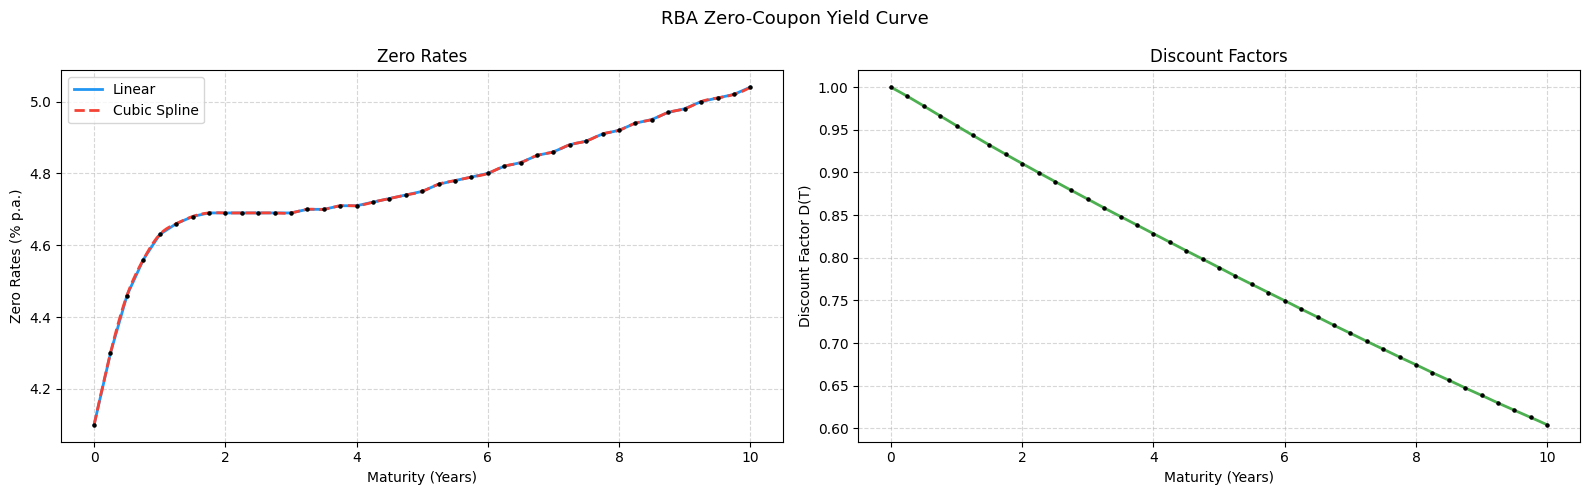

,Maturity (Years),Linear Zero Rates (% p.a.),Linear Discount Factor,Cubic Spline Zero Rates (% p.a.),Cubic Spline Discount Factor,Difference (bps)
,0.6000,4.5000,0.9734,4.5056,0.9733,0.5570
,1.3000,4.6640,0.9412,4.6643,0.9412,0.0275
,2.8000,4.6900,0.8769,4.6896,0.8769,-0.0450
,4.2000,4.7180,0.8202,4.7176,0.8203,-0.0435
,6.3000,4.8220,0.7380,4.8224,0.7380,0.0417
,8.5000,4.9500,0.6566,4.9500,0.6566,0.0000
,9.1000,4.9880,0.6351,4.9875,0.6352,-0.0519


In [ ]:
yield_curve.plot(compare=True)

yield_curve.compare_interpolation()

### 6.1 Interpretation: Zero Rates & Discount Factors

- The Australian yield curve(as of 30-04-2026) is upward sloping, indicating that long-term rates are higher than short-term rates. This yield curve shape is indicative of a normal economic environment.
- During 0 years (4.10%) to 1 year (4.63%) the curve rises steeply and then flattens between 2 years to 3 years. After this point, it resumes rising at a gradual rate out to 10 years (5.04%).
- This term structure is passed directly into `derivatives.py` via `get_discount_factor(T)`, ensuring every option is discounted at the correct maturity-matched rate.

### 6.2 Interpretation of Interpolation Methods 

- The difference between the linear and cubic spline interpolation is very small (< 1 basis point) across all maturities.
- Linear interpolation is sufficient given the quantity of RBA data. 
- In a sparser dataset, cubic spline interpolation would produce noticeably smoother and more accruate results.
- As a result, linear interpolation is used as the default throughout the platform.

## 7.0 Limitations

__Maturity Range:__ The RBA data series only has data up to 10 years. Therefore, options with maturities beyond 10 years cannot be priced without extrapolation assumptions. 

__Full Bootstrapping__: The RBA already provides zero-coupon rates so "full" bootstrapping method hasn't been followed. There were no steps taken to collect raw government bond prices from the market.

__Linear Interpolation:__ Although linear interpolation is a sufficient method for the construction of the yield curve, cubic splien interpolation could be used to produce a smoother curve. Cubic spline interpolation fits a smooth curved line through all the data points at once. In a professional setting, this is preferred because yield curves are smooth in practice. Linear interpolation can produce 'kinks' in the yield curve that can lead to slightly inaccurate discount factors between observed maturities.

__Static Snapshot__: The curve is built from a single day's observation which would typically be refreshed daily. In pratice, this would need to be automated in production to get the most recent data.

__Exclusively Australian Rates:__ The curve reflects Australian government bond yields. For non-Australian underlyings, a currency-matched curve would be required.